# House Price Prediction using Linear Regression

In [15]:
import pandas as pd


try:
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
    print('Datasets loaded successfully.')
except FileNotFoundError:
    print("Make sure 'train.csv' and 'test.csv' are uploaded to your Colab environment.")

    train_df = pd.DataFrame(train_data)
    test_df = pd.DataFrame(test_data)


print("\nFirst 5 rows of the training dataset:")
display(train_df.head())

Datasets loaded successfully.

First 5 rows of the training dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Exploratory Data Analysis (EDA)

In [16]:
print(f"Train dataset shape: {train_df.shape}")
print(f"Test dataset shape: {test_df.shape}")

print("\nInfo about the training dataset:")
train_df.info()

print("\nMissing values in the training dataset:")
missing_values = train_df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
display(missing_values)

Train dataset shape: (1460, 81)
Test dataset shape: (1459, 80)

Info about the training dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16 

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


## 3. Data Preprocessing for Improved Performance

In [17]:
from sklearn.preprocessing import StandardScaler

all_data = pd.concat((train_df.drop(['SalePrice'], axis=1), test_df)).reset_index(drop=True)

print(f"Combined data shape: {all_data.shape}")

numerical_cols = all_data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = all_data.select_dtypes(exclude=np.number).columns.tolist()

for col in numerical_cols:
    if all_data[col].isnull().any() and col != 'Id':
        all_data[col] = all_data[col].fillna(all_data[col].median())


for col in ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'MasVnrType', 'GarageType', 'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']:
    if col in categorical_cols:
        all_data[col] = all_data[col].fillna('None')

for col in categorical_cols:
    if all_data[col].isnull().any():
        all_data[col] = all_data[col].fillna(all_data[col].mode()[0])

print("\nMissing values after imputation:")
missing_after_imputation = all_data.isnull().sum()
missing_after_imputation = missing_after_imputation[missing_after_imputation > 0]
print(missing_after_imputation)

categorical_cols_processed = all_data.select_dtypes(exclude=np.number).columns.tolist()

all_data = pd.get_dummies(all_data, columns=categorical_cols_processed, dummy_na=False)

print(f"\nShape after one-hot encoding: {all_data.shape}")

X_train_processed = all_data[:len(train_df)].drop('Id', axis=1)
X_test_processed = all_data[len(train_df):].drop('Id', axis=1)
y_train_processed = train_df['SalePrice']

train_cols = X_train_processed.columns
test_cols = X_test_processed.columns

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test_processed[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train_processed[c] = 0

X_test_processed = X_test_processed[train_cols]


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

X_train_processed = pd.DataFrame(X_train_scaled, columns=X_train_processed.columns)
X_test_processed = pd.DataFrame(X_test_scaled, columns=X_test_processed.columns)

print(f"\nShape of processed X_train: {X_train_processed.shape}")
print(f"Shape of processed X_test: {X_test_processed.shape}")

display(X_train_processed.head())

Combined data shape: (2919, 80)

Missing values after imputation:
Series([], dtype: int64)

Shape after one-hot encoding: (2919, 300)

Shape of processed X_train: (1460, 299)
Shape of processed X_test: (1459, 299)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,0.073375,-0.212720,-0.207142,0.651479,-0.517200,1.050994,0.878668,0.514104,0.575425,-0.288653,...,-0.058621,-0.301962,-0.045376,0.390293,-0.272616,-0.052414,-0.091035,-0.117851,0.467651,-0.305995
1,-0.872563,0.468158,-0.091886,-0.071836,2.179628,0.156734,-0.429577,-0.570750,1.171992,-0.288653,...,-0.058621,-0.301962,-0.045376,0.390293,-0.272616,-0.052414,-0.091035,-0.117851,0.467651,-0.305995
2,0.073375,-0.076544,0.073480,0.651479,-0.517200,0.984752,0.830215,0.325915,0.092907,-0.288653,...,-0.058621,-0.301962,-0.045376,0.390293,-0.272616,-0.052414,-0.091035,-0.117851,0.467651,-0.305995
3,0.309859,-0.439679,-0.096897,0.651479,-0.517200,-1.863632,-0.720298,-0.570750,-0.499274,-0.288653,...,-0.058621,-0.301962,-0.045376,0.390293,3.668167,-0.052414,-0.091035,-0.117851,-2.138345,-0.305995
4,0.073375,0.649725,0.375148,1.374795,-0.517200,0.951632,0.733308,1.366489,0.463568,-0.288653,...,-0.058621,-0.301962,-0.045376,0.390293,-0.272616,-0.052414,-0.091035,-0.117851,0.467651,-0.305995


## 4.train the Linear Regression model with processed data

In [20]:
model_enhanced = LinearRegression()
model_enhanced.fit(X_train_processed, y_train_processed)

print("Enhanced Linear Regression model trained successfully.")
print(f"Model coefficients (first 5): {model_enhanced.coef_[:5]}")
print(f"Model intercept: {model_enhanced.intercept_}")

Enhanced Linear Regression model trained successfully.
Model coefficients (first 5): [-2324.28659461   937.54525217  7027.58830165  9363.19301731
  6450.86810896]
Model intercept: 180921.19589041095


In [21]:
y_train_pred_enhanced = model_enhanced.predict(X_train_processed)

mse_train_enhanced = mean_squared_error(y_train_processed, y_train_pred_enhanced)
r2_train_enhanced = r2_score(y_train_processed, y_train_pred_enhanced)

print(f"Enhanced Training Mean Squared Error: {mse_train_enhanced:.2f}")
print(f"Enhanced Training R-squared: {r2_train_enhanced:.2f}")

y_test_pred_enhanced = model_enhanced.predict(X_test_processed)

if 'SalePrice' in test_df.columns:
    y_test_original = test_df['SalePrice']
    mse_test_enhanced = mean_squared_error(y_test_original, y_test_pred_enhanced)
    r2_test_enhanced = r2_score(y_test_original, y_test_pred_enhanced)
    print(f"\nEnhanced Test Mean Squared Error: {mse_test_enhanced:.2f}")
    print(f"Enhanced Test R-squared: {r2_test_enhanced:.2f}")
else:
    print("\nTest dataset does not contain 'SalePrice' for full evaluation. Displaying first 5 enhanced predictions:")
    print(y_test_pred_enhanced[:5])

Enhanced Training Mean Squared Error: 421083337.03
Enhanced Training R-squared: 0.93

Test dataset does not contain 'SalePrice' for full evaluation. Displaying first 5 enhanced predictions:
[112601.36736057 159581.97629369 186533.46460717 197079.45791121
 205424.87005474]


## 5. Visualization of Enhanced Predictions

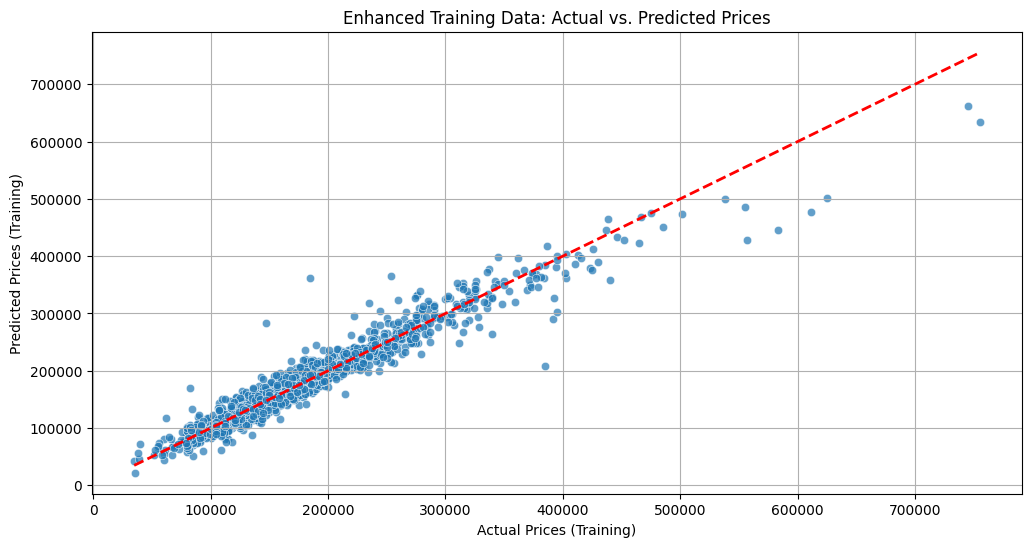

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.scatterplot(x=y_train_processed, y=y_train_pred_enhanced, alpha=0.7)
plt.plot([y_train_processed.min(), y_train_processed.max()], [y_train_processed.min(), y_train_processed.max()], '--r', linewidth=2)
plt.title('Enhanced Training Data: Actual vs. Predicted Prices')
plt.xlabel('Actual Prices (Training)')
plt.ylabel('Predicted Prices (Training)')
plt.grid(True)
plt.show()

if 'SalePrice' in test_df.columns:
    plt.figure(figsize=(12, 6))
    sns.scatterplot(x=y_test_original, y=y_test_pred_enhanced, alpha=0.7)
    plt.plot([y_test_original.min(), y_test_original.max()], [y_test_original.min(), y_test_original.max()], '--r', linewidth=2)
    plt.title('Enhanced Test Data: Actual vs. Predicted Prices')
    plt.xlabel('Actual Prices (Test)')
    plt.ylabel('Predicted Prices (Test)')
    plt.grid(True)
    plt.show()


## 7. Test Data Predictions

In [23]:
print("Predictions for the entire test dataset:")
display(pd.DataFrame({'SalePrice_Predicted': y_test_pred_enhanced}))

predictions_df = pd.DataFrame({'SalePrice_Predicted': y_test_pred_enhanced}, index=test_df.index)
predictions_df.to_csv('test_predictions.csv', index=False)
print("\nPredictions saved to 'test_predictions.csv'")

Predictions for the entire test dataset:


,SalePrice_Predicted
0,112601.367361
1,159581.976294
2,186533.464607
3,197079.457911
4,205424.870055
...,...
1454,84391.732664
1455,79627.165093
1456,179093.274436
1457,115230.396673



Predictions saved to 'test_predictions.csv'
